# CH03_측정

---
## 3.1 전쟁기간 중 민간인 희생자 측정
---

```
LYALL, J., BLAIR, G., & IMAI, K. (2013). Explaining Support for Combatants during Wartime: A Survey Experiment in Afghanistan. American Political Science Review, 107(4), 679–705.
doi:10.1017/S0003055413000403

Blair, G., Imai, K. and Lyall, J. (2014), Comparing and Combining List and Endorsement Experiments: Evidence from Afghanistan. American Journal of Political Science, 58: 1043-1063.
https://doi.org/10.1111/ajps.12086

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
os.chdir('/home/user/repo/studies/qss/data')

In [5]:
afghan = pd.read_csv('afghan.csv')
afghan.head()

,province,district,village.id,age,educ.years,employed,income,violent.exp.ISAF,violent.exp.taliban,list.group,list.response
0,Logar,Baraki Barak,80,26,10,0,"2,001-10,000",0.0,0.0,control,0
1,Logar,Baraki Barak,80,49,3,1,"2,001-10,000",0.0,0.0,control,1
2,Logar,Baraki Barak,80,60,0,1,"2,001-10,000",1.0,0.0,control,1
3,Logar,Baraki Barak,80,34,14,1,"2,001-10,000",0.0,0.0,ISAF,3
4,Logar,Baraki Barak,80,21,12,1,"2,001-10,000",0.0,0.0,ISAF,3


In [6]:
afghan.describe().round(2)

,village.id,age,educ.years,employed,violent.exp.ISAF,violent.exp.taliban,list.response
count,2754.00,2754.00,2754.00,2754.00,2729.00,2700.00,2754.00
mean,103.62,32.39,4.00,0.58,0.37,0.33,1.61
std,58.92,12.29,4.75,0.49,0.48,0.47,0.99
min,1.00,15.00,0.00,0.00,0.00,0.00,0.00
25%,53.00,22.00,0.00,0.00,0.00,0.00,1.00
50%,104.50,30.00,1.00,1.00,0.00,0.00,2.00
75%,153.00,40.00,8.00,1.00,1.00,1.00,2.00
max,204.00,80.00,18.00,1.00,1.00,1.00,4.00


In [8]:
afghan['income'] = afghan['income'].astype('category').cat.reorder_categories(
    ['less than 2,000', '2,001-10,000', '10,001-20,000', '20,001-30,000', 
     'over 30,000']
)

In [9]:
afghan['income'].value_counts(sort=False, dropna=False)

income
less than 2,000     457
2,001-10,000       1420
10,001-20,000       616
20,001-30,000        93
over 30,000          14
NaN                 154
Name: count, dtype: int64

In [11]:
pd.crosstab(afghan['violent.exp.ISAF'], afghan['violent.exp.taliban'], 
            rownames=['ISAF'], colnames=['Taliban'] ,normalize=True)

Taliban,0.0,1.0
ISAF,,
0.0,0.495345,0.131844
1.0,0.176909,0.195903


---
## 3.2 결측값 다루기
---

In [12]:
afghan['income'].head(10)

0     2,001-10,000
1     2,001-10,000
2     2,001-10,000
3     2,001-10,000
4     2,001-10,000
5              NaN
6    10,001-20,000
7     2,001-10,000
8     2,001-10,000
9              NaN
Name: income, dtype: category
Categories (5, str): ['less than 2,000', '2,001-10,000', '10,001-20,000', '20,001-30,000', 'over 30,000']

In [15]:
afghan['income'].isna().head(10)

0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
8    False
9     True
Name: income, dtype: bool

In [16]:
afghan['income'].isnull().sum()

np.int64(154)

In [17]:
afghan['income'].isnull().mean()

np.float64(0.05591866376180102)

In [18]:
x = pd.Series([1,2,3,np.nan])

x.mean()

np.float64(2.0)

In [19]:
x.mean(skipna=False)

np.float64(nan)

In [20]:
pd.crosstab(afghan['violent.exp.ISAF'].fillna('Nonresponse'),
            afghan['violent.exp.taliban'].fillna('Nonresponse'),
            rownames=['ISAF'], colnames=['Taliban'], normalize=True)

Taliban,0.0,1.0,Nonresponse
ISAF,,,
0.0,0.482934,0.128540,0.007988
1.0,0.172476,0.190995,0.007988
Nonresponse,0.002542,0.002905,0.003631


In [21]:
afghan_sub = afghan.dropna()

print(afghan.shape[0])
print(afghan_sub.shape[0])
print(afghan['income'].dropna().shape[0])

2754
2554
2600


---
## 3.3 일변량 분포 시각화
---

### 3.3.1 막대 그래프

In [23]:
ISAF_ptable = (afghan['violent.exp.ISAF'].value_counts(normalize=True, dropna=False).reset_index())
ISAF_ptable

,violent.exp.ISAF,proportion
0,0.0,0.619463
1,1.0,0.371460
2,NaN,0.009078


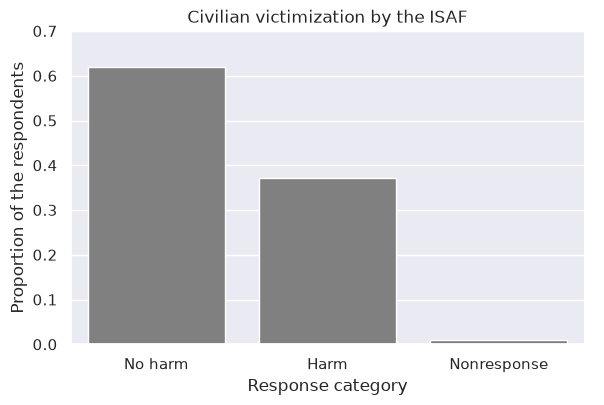

In [28]:
ISAF_ptable['response'] = ['No harm', 'Harm', 'Nonresponse']

sns.catplot(
    data=ISAF_ptable, x='response', y='proportion', color='gray',
    kind='bar', estimator=sum, height=4, aspect=1.5
).set(title='Civilian victimization by the ISAF',
      xlabel='Response category', ylabel='Proportion of the respondents',
      ylim=(0, 0.7));

In [29]:
Taliban_ptalbe = (afghan['violent.exp.taliban'].value_counts(normalize=True, dropna=False).reset_index())
Taliban_ptalbe

,violent.exp.taliban,proportion
0,0.0,0.657952
1,1.0,0.322440
2,NaN,0.019608


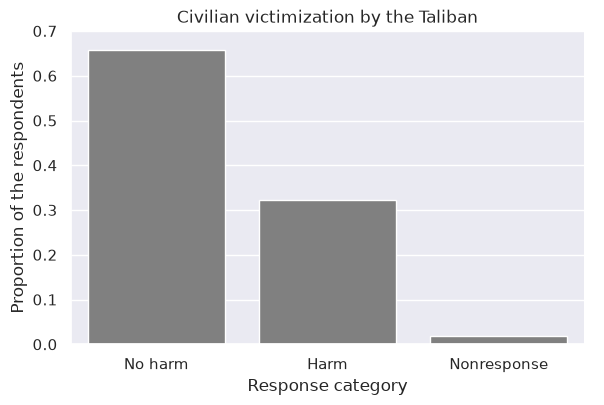

In [30]:
Taliban_ptalbe['response'] = ['No harm', 'Harm', 'Nonresponse']

sns.catplot(
    data=Taliban_ptalbe, x='response', y='proportion', color='gray',
    kind='bar', estimator=sum, height=4, aspect=1.5,
).set(title='Civilian victimization by the Taliban',
      xlabel='Response category', ylabel='Proportion of the respondents',
      ylim=(0, 0.7));

### 3.3.2 히스토그램

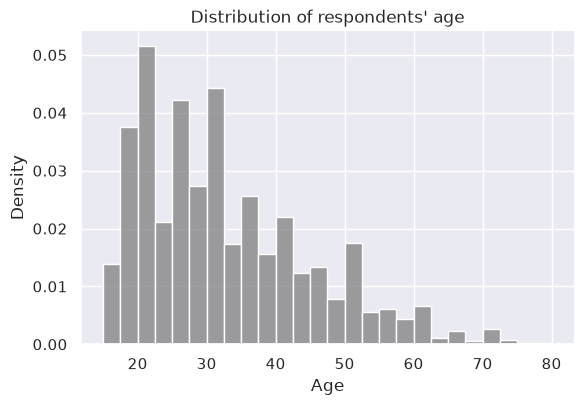

In [41]:
sns.displot(
    data=afghan, x='age', stat='density', color='gray',
    height=4, aspect=1.5
).set(title="Distribution of respondents' age", xlabel='Age');

Text(1.5, 0.5, 'median')

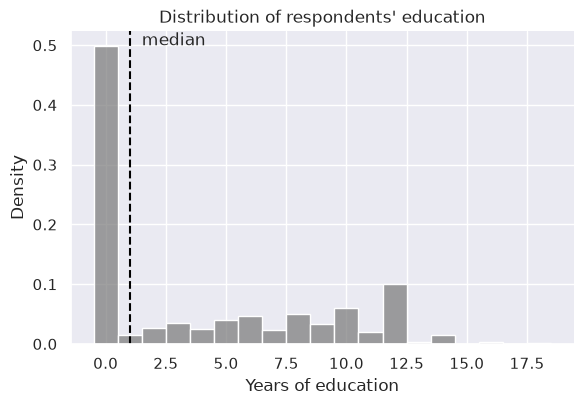

In [42]:
sns.displot(
    data=afghan, x='educ.years', stat='density', color='gray',
    binrange=(-0.5, 18.5), binwidth=1, height=4, aspect=1.5
).set(title="Distribution of respondents' education",
      xlabel='Years of education')

plt.axvline(x=afghan['educ.years'].median(), color='black', linestyle='--')

plt.text(x=1.5, y=.5, s='median')

### 3.3.3 박스 플롯

<Axes: ylabel='age'>

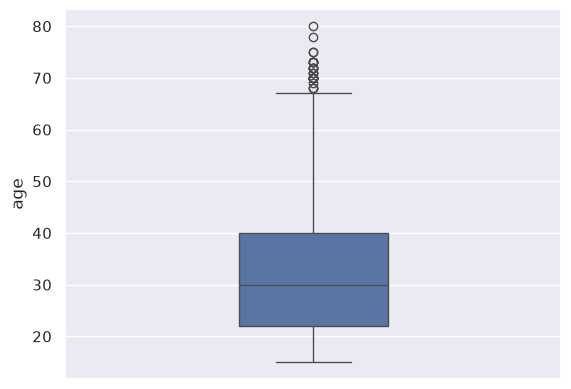

In [56]:
sns.boxplot(data=afghan['age'], width=.3)

In [44]:
afghan['province'] = afghan.province.astype('category')
afghan['province'].cat.categories

Index(['Helmand', 'Khost', 'Kunar', 'Logar', 'Uruzgan'], dtype='str')

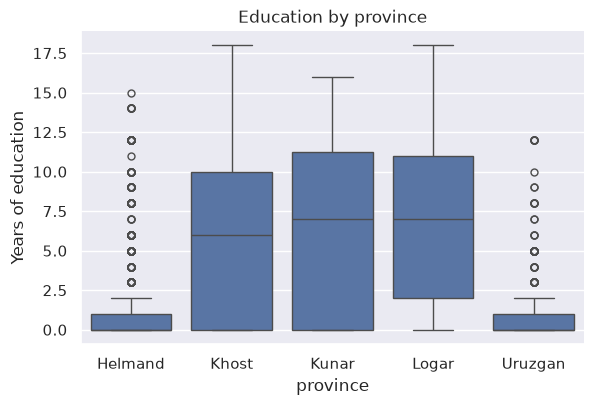

In [47]:
sns.catplot(
    data=afghan, x='province', y='educ.years', kind='box', height=4, aspect=1.5 
).set(title='Education by province', ylabel='Years of education');

In [58]:
afghan.groupby('province')['violent.exp.taliban'].mean()

province
Helmand    0.504222
Khost      0.233227
Kunar      0.303030
Logar      0.080247
Uruzgan    0.454545
Name: violent.exp.taliban, dtype: float64

In [59]:
afghan.groupby('province')['violent.exp.ISAF'].mean()

province
Helmand    0.541023
Khost      0.242424
Kunar      0.398990
Logar      0.144033
Uruzgan    0.496042
Name: violent.exp.ISAF, dtype: float64

In [65]:
sns.catplot(
    data=afghan, x='province', y='educ.years', kind='box', color='gray',
    height=4, aspect=1.5
).set(title='Education by province', xlabel='', ylabel='Years of education');

plt.savefig('education-by-province.png', bbox_inches='tight')

plt.close()

---
## 3.4 설문조사 샘플링
---

### 3.4.1 무작위화의 역할

In [66]:
afghan_village = pd.read_csv('afghan-village.csv')

In [75]:
afghan_village.head()

,altitude,population,village.surveyed
0,1959.0800,197,1
1,2425.8799,744,0
2,2236.6001,179,1
3,1691.7600,225,0
4,1928.0400,379,0


In [78]:
afghan_village['village_surveyed_desc'] = (
    np.where(afghan_village['village.surveyed']==1, 'Sampled', 'Nonsampled')
)

afghan_village['village_surveyed_desc'].head()

0       Sampled
1    Nonsampled
2       Sampled
3    Nonsampled
4    Nonsampled
Name: village_surveyed_desc, dtype: str

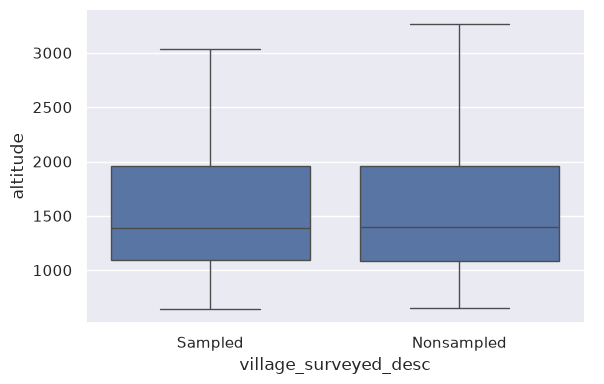

In [83]:
sns.catplot(
    data=afghan_village, x='village_surveyed_desc', y='altitude', kind='box',
    height=4, aspect=1.5
);

In [84]:
afghan_village['log_pop'] = np.log(afghan_village['population'])

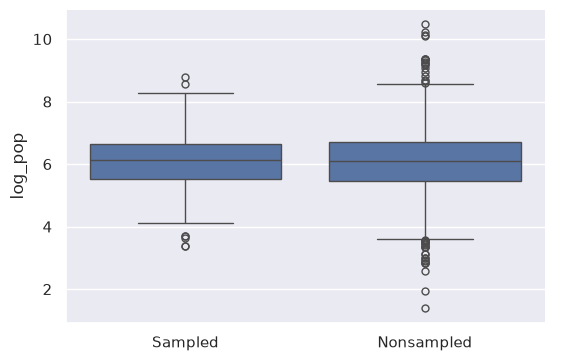

In [86]:
sns.catplot(
    data=afghan_village, x='village_surveyed_desc', y='log_pop', kind='box',
    height=4, aspect=1.4
).set(xlabel='')

### 3.4.2 무응답과 다른 편향 발생 요인

In [96]:
afghan.groupby('province')['violent.exp.taliban'].apply(lambda x: x.isnull().mean())

province
Helmand    0.030409
Khost      0.006349
Kunar      0.000000
Logar      0.000000
Uruzgan    0.062016
Name: violent.exp.taliban, dtype: float64

In [97]:
afghan.groupby('province')['violent.exp.ISAF'].apply(lambda x: x.isnull().mean())

province
Helmand    0.016374
Khost      0.004762
Kunar      0.000000
Logar      0.000000
Uruzgan    0.020672
Name: violent.exp.ISAF, dtype: float64

In [99]:
afghan.loc[afghan['list.group'] == 'ISAF', 'list.response'].mean() - afghan.loc[afghan['list.group'] == 'control', 'list.response'].mean()

np.float64(0.0490196078431373)

In [102]:
afghan.loc[afghan['list.group'] == 'taliban', 'list.response'].mean() - afghan.loc[afghan['list.group'] == 'control', 'list.response'].mean()

np.float64(0.224400871459695)

In [103]:
afghan['list.group'] = afghan['list.group'].astype('category').cat.reorder_categories(['control', 'ISAF', 'taliban'])

In [104]:
pd.crosstab(afghan['list.response'], afghan['list.group'],
            colnames=['group'], rownames=['response'])

group,control,ISAF,taliban
response,,,
0,188,174,0
1,265,278,433
2,265,260,287
3,200,182,198
4,0,24,0


---
## 3.5 정치적 양극화 측정하기
---

```
McCarty, N. M., Poole, K. T., & Rosenthal, H. (2006). Polarized America: The Dance of Ideology and Unequal Riches. Cambridge: MIT Press.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
os.chdir('/home/user/repo/studies/qss/data')

---
## 3.6 이변량 관계 요약하기
---

In [2]:
congress = pd.read_csv('congress.csv')
congress.head()

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
4,80,4,ALABAMA,Democrat,HOBBS S.,-0.082,1.066


### 3.6.1 산점도

In [3]:
congress.info()

<class 'pandas.DataFrame'>
RangeIndex: 14552 entries, 0 to 14551
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   congress  14552 non-null  int64  
 1   district  14552 non-null  int64  
 2   state     14552 non-null  str    
 3   party     14552 non-null  str    
 4   name      14552 non-null  str    
 5   dwnom1    14552 non-null  float64
 6   dwnom2    14552 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 795.9 KB


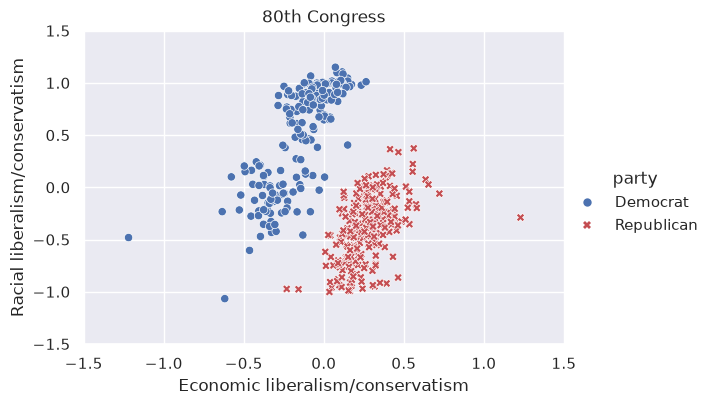

In [4]:
xlab = 'Economic liberalism/conservatism'
ylab = 'Racial liberalism/conservatism'
lim = (-1.5, 1.5)

sns.relplot(
    data=congress.loc[(congress['congress'] == 80) & (congress['party'] != 'Other')],
    x='dwnom1', y='dwnom2', hue='party', style='party', palette=['b', 'r'],
    height=4, aspect=1.5
).set(title='80th Congress', xlabel=xlab, ylabel=ylab, xlim=lim, ylim=lim);

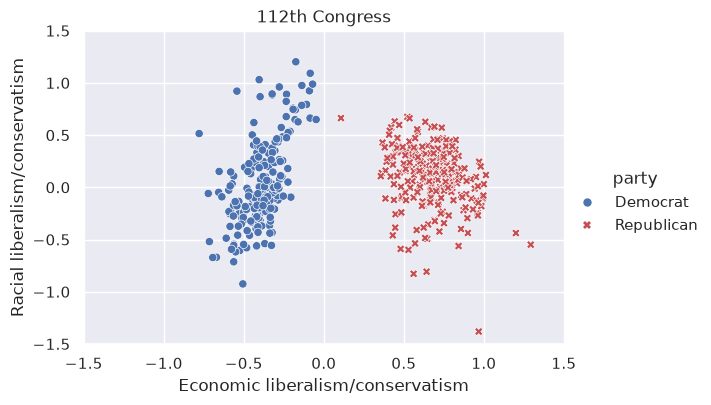

In [5]:
sns.relplot(
    data=congress.loc[(congress['congress'] == 112) & (congress['party'] != 'Other')],
    x='dwnom1', y='dwnom2', hue='party', style='party', palette=['b', 'r'],
    height=4, aspect=1.5
).set(title='112th Congress', xlabel=xlab, ylabel=ylab, xlim=lim, ylim=lim);

In [6]:
dwn1_med = (congress.loc[congress.party != 'Other'].groupby(['party', 'congress'])['dwnom1'].median().reset_index())
dwn1_med

,party,congress,dwnom1
0,Democrat,80,-0.1265
1,Democrat,81,-0.2070
2,Democrat,82,-0.1790
3,Democrat,83,-0.1740
4,Democrat,84,-0.2225
...,...,...,...
61,Republican,108,0.5540
62,Republican,109,0.5825
63,Republican,110,0.6180
64,Republican,111,0.6550


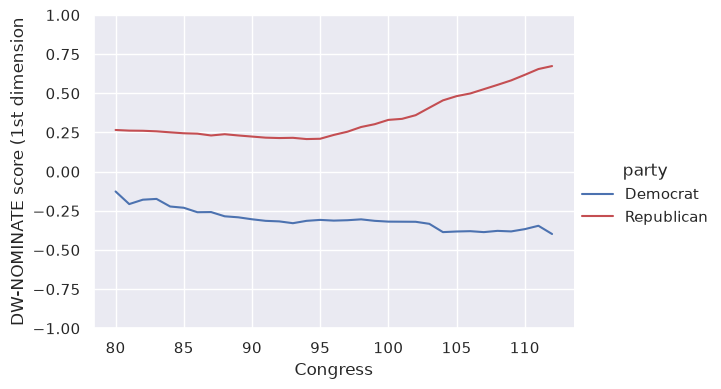

In [7]:
sns.relplot(
    data=dwn1_med, x='congress', y='dwnom1', hue='party', kind='line',
    palette=['b', 'r'], height=4, aspect=1.5
).set(ylim=(-1,1), xlabel='Congress', ylabel='DW-NOMINATE score (1st dimension');

### 3.6.2 상관관계

In [8]:
gini = pd.read_csv('USGini.csv')
gini.head()

,Unnamed: 0,year,gini
0,1,1947,0.376
1,2,1948,0.371
2,3,1949,0.378
3,4,1950,0.379
4,5,1951,0.363


In [9]:
med_diff = (
    dwn1_med.loc[dwn1_med.party == 'Republican', 'dwnom1'].reset_index(drop=True) -
    dwn1_med.loc[dwn1_med.party == 'Democrat', 'dwnom1'].reset_index(drop=True)
)

med_diff

0     0.3925
1     0.4690
2     0.4400
3     0.4315
4     0.4735
5     0.4755
6     0.5015
7     0.4890
8     0.5240
9     0.5225
10    0.5280
11    0.5310
12    0.5320
13    0.5450
14    0.5220
15    0.5180
16    0.5470
17    0.5650
18    0.5895
19    0.6170
20    0.6495
21    0.6565
22    0.6805
23    0.7410
24    0.8410
25    0.8640
26    0.8790
27    0.9125
28    0.9320
29    0.9640
30    0.9850
31    1.0005
32    1.0720
Name: dwnom1, dtype: float64

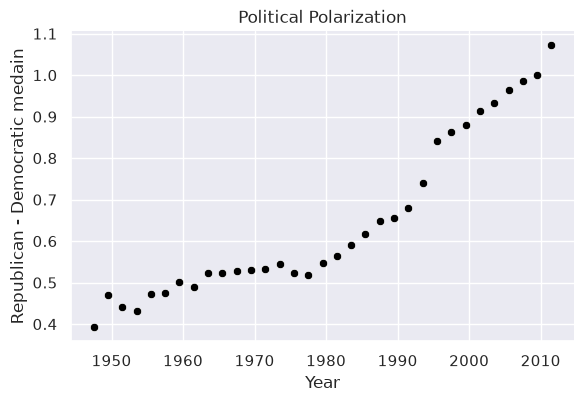

In [10]:
sns.relplot(
    x=np.arange(1947.5, 2012.5, 2), y=med_diff, color='black',
    height=4, aspect=1.5
).set(title='Political Polarization', xlabel='Year', ylabel='Republican - Democratic medain');

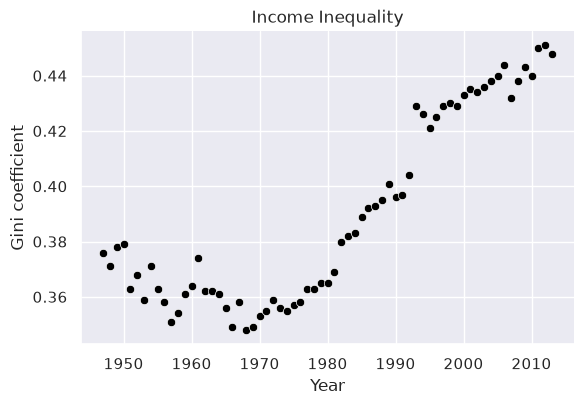

In [11]:
sns.relplot(
    data=gini, x='year', y='gini', color='black',
    height=4, aspect=1.5
).set(title='Income Inequality', ylabel='Gini coefficient', xlabel='Year');

In [12]:
np.corrcoef([gini['gini'].iloc[np.arange(1, gini.shape[0], 2)], med_diff])

array([[1.        , 0.94181282],
       [0.94181282, 1.        ]])

In [13]:
gini['gini'].iloc[np.arange(1, gini.shape[0], 2)].reset_index(drop=True).corr(med_diff)

np.float64(0.9418128160619333)

### 3.6.3 Q-Q 플롯

In [14]:
dem112 = congress.loc[(congress['congress'] == 112) & (congress['party'] == 'Democrat')]
rep112 = congress.loc[(congress['congress'] == 112) & (congress['party'] == 'Republican')]

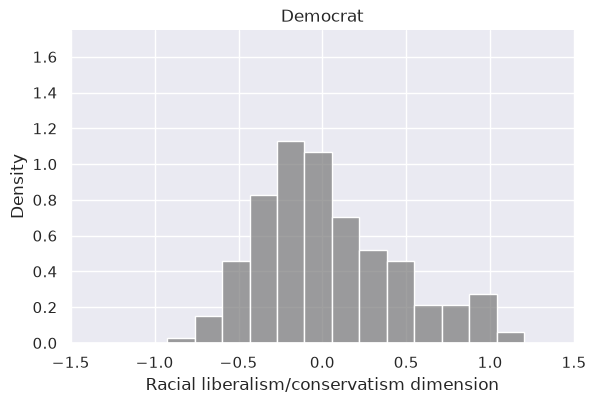

In [15]:
sns.displot(
    data=dem112, x='dwnom2', stat='density', color='gray',
    height=4, aspect=1.5
).set(title='Democrat', xlabel='Racial liberalism/conservatism dimension', 
      xlim=(-1.5, 1.5), ylim=(0, 1.75));

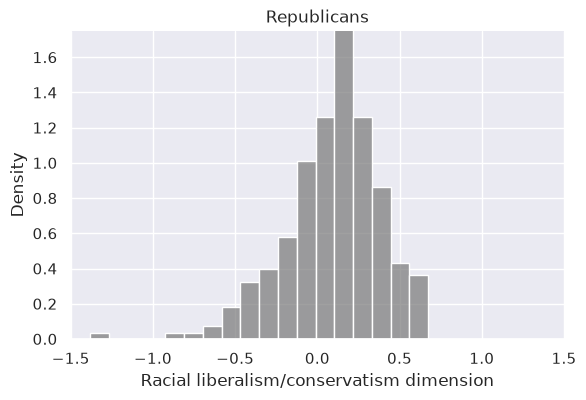

In [16]:
sns.displot(
    data=rep112, x='dwnom2', stat='density', color='gray',
    height=4, aspect=1.5
).set(title='Republicans', xlabel='Racial liberalism/conservatism dimension', 
      xlim=(-1.5, 1.5), ylim=(0, 1.75));

In [17]:
quantiles = np.linspace(0, 1, 101)

demq = dem112.dwnom2.quantile(quantiles)
repq = rep112.dwnom2.quantile(quantiles)

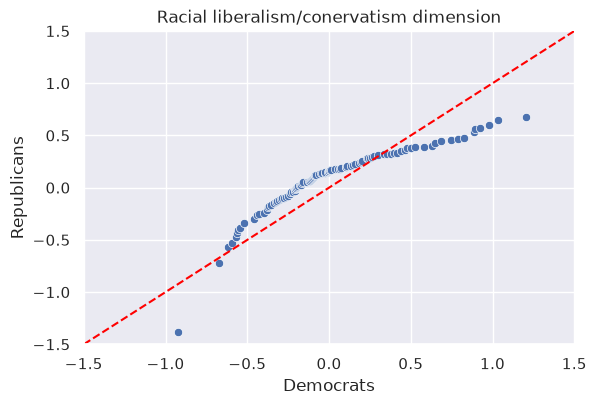

In [18]:
sns.relplot(
    x=demq, y=repq, height=4, aspect=1.5
).set(xlabel='Democrats', ylabel='Republicans',
      title='Racial liberalism/conervatism dimension',
      ylim=(-1.5, 1.5), xlim=(-1.5, 1.5))

plt.gca().axline((0,0), slope=1, color='red', linestyle='--');

---
## 3.7 군집화
---

### 3.7.1 행렬

In [19]:
x = np.array([10, 20, 30, 40, 50])
x

array([10, 20, 30, 40, 50])

In [20]:
y = np.arange(10, 60, 10)
y

array([10, 20, 30, 40, 50])

In [21]:
z = np.random.uniform(50, 100, 10)
z

array([86.70773519, 96.37669953, 72.12510682, 59.37396238, 50.03894811,
       85.62860196, 79.0569108 , 67.91527942, 83.0608922 , 78.88246575])

In [22]:
z[0]

np.float64(86.70773518997159)

In [23]:
z[:5]

array([86.70773519, 96.37669953, 72.12510682, 59.37396238, 50.03894811])

In [24]:
z[4:]

array([50.03894811, 85.62860196, 79.0569108 , 67.91527942, 83.0608922 ,
       78.88246575])

In [25]:
z * .25

array([21.6769338 , 24.09417488, 18.03127671, 14.84349059, 12.50973703,
       21.40715049, 19.7642277 , 16.97881985, 20.76522305, 19.72061644])

In [26]:
np.where(z>75, z*.25, z*.75)

array([21.6769338 , 24.09417488, 54.09383012, 44.53047178, 37.52921109,
       21.40715049, 19.7642277 , 50.93645956, 20.76522305, 19.72061644])

In [27]:
z.sum()

np.float64(759.1666021530895)

In [28]:
z.mean()

np.float64(75.91666021530895)

In [29]:
mat = np.arange(0, 10).reshape(5, 2)
mat

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [8, 9]])

In [30]:
mat[0]

array([0, 1])

In [31]:
mat[:,1]

array([1, 3, 5, 7, 9])

In [32]:
mat[:,1:]

array([[1],
       [3],
       [5],
       [7],
       [9]])

In [33]:
mat[:2, 1]

array([1, 3])

In [34]:
mat.sum(0)

array([20, 25])

In [35]:
mat.sum(1)

array([ 1,  5,  9, 13, 17])

In [36]:
mat.std(0)

array([2.82842712, 2.82842712])

In [37]:
df = pd.DataFrame({'x':['a','b','c'], 'y':[1,2,3]})
df.dtypes

x      str
y    int64
dtype: object

In [38]:
df

,x,y
0,a,1
1,b,2
2,c,3


In [39]:
np.array(df)

array([['a', 1],
       ['b', 2],
       ['c', 3]], dtype=object)

In [40]:
np.array([1,2,'a','b'])

array(['1', '2', 'a', 'b'], dtype='<U21')

### 3.7.2 객체지향

In [41]:
congress

,congress,district,state,party,name,dwnom1,dwnom2
0,80,0,USA,Democrat,TRUMAN,-0.276,0.016
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
4,80,4,ALABAMA,Democrat,HOBBS S.,-0.082,1.066
...,...,...,...,...,...,...,...
14547,112,5,WISCONS,Republican,SENSENBR,1.200,-0.438
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193


In [42]:
type(congress)

pandas.DataFrame

In [43]:
dir(congress)[:15]

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__']

In [44]:
[item for item in dir(congress) if not item.startswith('_')][:15]

['T',
 'abs',
 'add',
 'add_prefix',
 'add_suffix',
 'agg',
 'aggregate',
 'align',
 'all',
 'any',
 'apply',
 'asfreq',
 'asof',
 'assign',
 'astype']

In [45]:
congress['party'].value_counts()

party
Democrat      8132
Republican    6401
Other           19
Name: count, dtype: int64

In [46]:
congress.shape

(14552, 7)

### 3.7.3 k-means

In [47]:
from sklearn.cluster import KMeans

In [48]:
dwnom80 = congress.loc[congress['congress']==80, ['dwnom1', 'dwnom2']].copy()
dwnom112 = congress.loc[congress['congress']==112, ['dwnom1', 'dwnom2']].copy()

In [49]:
k80two = KMeans(n_clusters=2, n_init=5)
k112two = KMeans(n_clusters=2, n_init=5)

In [50]:
k80two.fit(dwnom80)
k112two.fit(dwnom112)

k80two_labels = k80two.predict(dwnom80)
k112two_labels = k112two.predict(dwnom112)

type(k80two_labels)

numpy.ndarray

In [51]:
[item for item in dir(k80two) if not item.startswith('_')]

['algorithm',
 'cluster_centers_',
 'copy_x',
 'feature_names_in_',
 'fit',
 'fit_predict',
 'fit_transform',
 'get_feature_names_out',
 'get_metadata_routing',
 'get_params',
 'inertia_',
 'init',
 'labels_',
 'max_iter',
 'n_clusters',
 'n_features_in_',
 'n_init',
 'n_iter_',
 'predict',
 'random_state',
 'score',
 'set_fit_request',
 'set_output',
 'set_params',
 'set_score_request',
 'tol',
 'transform',
 'verbose']

In [52]:
k80two.cluster_centers_

array([[-0.04843704,  0.78272593],
       [ 0.14681029, -0.33892926]])

In [53]:
k112two.cluster_centers_

array([[ 0.67767355,  0.09061157],
       [-0.39126866,  0.03260696]])

In [56]:
pd.crosstab(congress.loc[congress.congress == 80, 'party'], k80two_labels, colnames=['cluster'])

cluster,0,1
party,,
Democrat,132,62
Other,0,2
Republican,3,247


In [57]:
pd.crosstab(congress.loc[congress.congress == 112, 'party'], k112two_labels, colnames=['cluster'])

cluster,0,1
party,,
Democrat,0,200
Republican,242,1


In [58]:
k80four = KMeans(n_clusters=4, n_init=5)
k112four = KMeans(n_clusters=4, n_init=5)

k80four.fit(dwnom80)
k112four.fit(dwnom112)

k80four_labels = k80four.predict(dwnom80)
k112four_labels = k112four.predict(dwnom112)

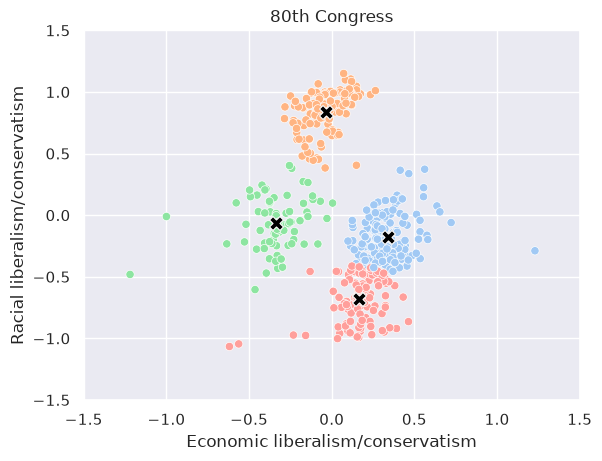

In [60]:
fix, ax = plt.subplots(1,1)

sns.scatterplot(
    data=dwnom80, x='dwnom1', y='dwnom2', hue=k80four_labels, legend=False,
    palette='pastel', ax=ax
).set(title='80th Congress', xlabel=xlab, ylabel=ylab, xlim=lim, ylim=lim)

sns.scatterplot(
   x=k80four.cluster_centers_[:,0], y=k80four.cluster_centers_[:,1],
   legend=False, color='black', s=100, marker='X', ax=ax
);

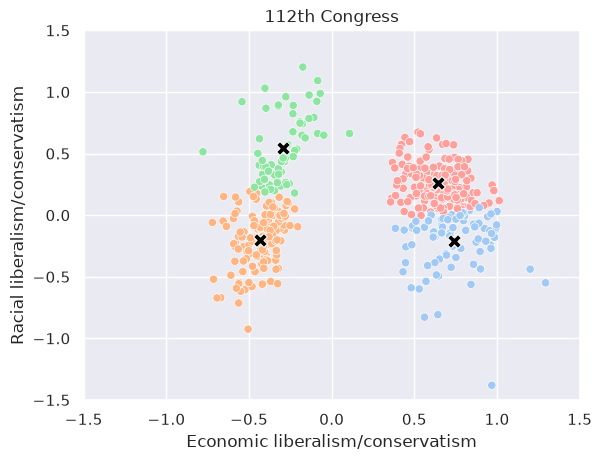

In [62]:
fix, ax = plt.subplots(1,1)

sns.scatterplot(
    data=dwnom112, x='dwnom1', y='dwnom2', hue=k112four_labels, legend=False,
    palette='pastel', ax=ax
).set(title='112th Congress', xlabel=xlab, ylabel=ylab, xlim=lim, ylim=lim)

sns.scatterplot(
   x=k112four.cluster_centers_[:,0], y=k112four.cluster_centers_[:,1],
   legend=False, color='black', s=100, marker='X', ax=ax
);

---
## 3.9 연습문제
---

### 3.9.1 동성혼에 대한 인식 변화: 재논의

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
os.chdir('/home/user/repo/studies/qss/data')

In [3]:
gay = pd.read_csv('gayreshaped.csv')
ccap = pd.read_csv('ccap2012.csv')

In [4]:
gay.head()

,study,treatment,therm1,therm2,therm3,therm4
0,1,No Contact,91,91.0,NaN,NaN
1,1,No Contact,72,72.0,NaN,NaN
2,1,No Contact,69,69.0,NaN,NaN
3,1,No Contact,51,51.0,NaN,NaN
4,1,Recycling Script by Gay Canvasser,50,48.0,NaN,NaN


In [5]:
ccap.head()

,Unnamed: 0,caseid,gaytherm
0,1,328,50.0
1,2,324,95.0
2,3,100,16.0
3,4,584,50.0
4,5,63,58.0


Q1

In [6]:
gay['treatment'].value_counts()

treatment
No Contact                                        6441
Same-Sex Marriage Script by Gay Canvasser         2389
Recycling Script by Gay Canvasser                 1046
Recycling Script by Straight Canvasser            1039
Same-Sex Marriage Script by Straight Canvasser    1033
Name: count, dtype: int64

In [7]:
gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 1), 'therm1'].dropna().corr(gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 1), 'therm2'].dropna())

np.float64(0.9975816546030558)

In [8]:
gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 1), 'therm1'].corr(gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 1), 'therm2'])

np.float64(0.9975816546030558)

Q2

In [9]:
gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 2), 'therm1':'therm4'].corr()

,therm1,therm2,therm3,therm4
therm1,1.000000,0.973445,0.959408,0.970902
therm2,0.973445,1.000000,0.930829,0.943662
therm3,0.959408,0.930829,1.000000,0.934325
therm4,0.970902,0.943662,0.934325,1.000000


Q3

In [10]:
gay_s2 = gay.loc[(gay['treatment'] == 'No Contact') & (gay['study'] == 2), 'therm1':]

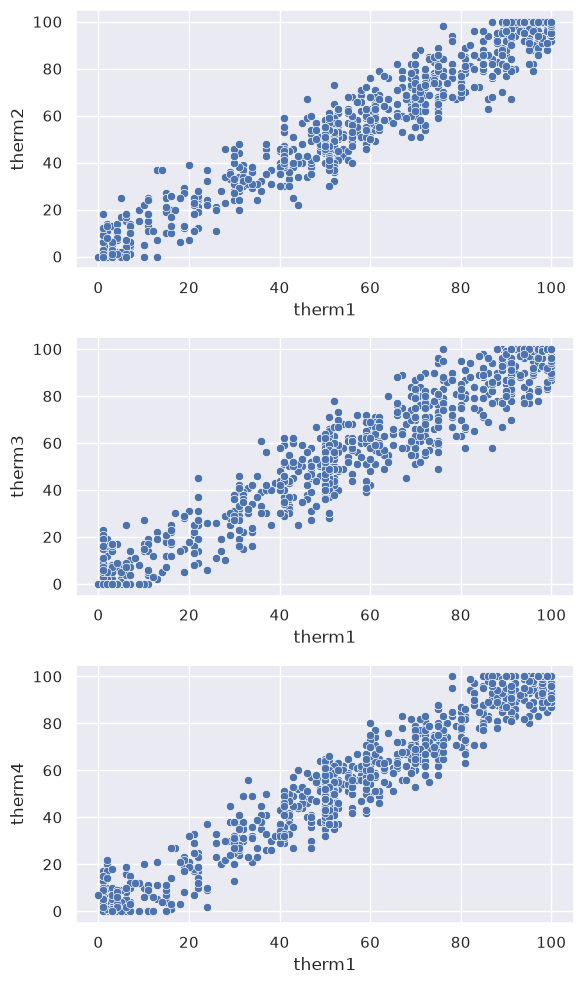

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(6, 10))

for idx, i in enumerate(range(2,5)):
    sns.scatterplot(data=gay_s2, x='therm1', y=f'therm{i}', ax=ax[idx])

plt.tight_layout();

Q4

In [15]:
print(ccap['gaytherm'].isna().sum(), len(ccap))
print(gay.loc[gay['study'] == 1, 'therm1'].isna().sum(), len(gay.loc[gay['study'] == 1]))

3097 43998
0 9507


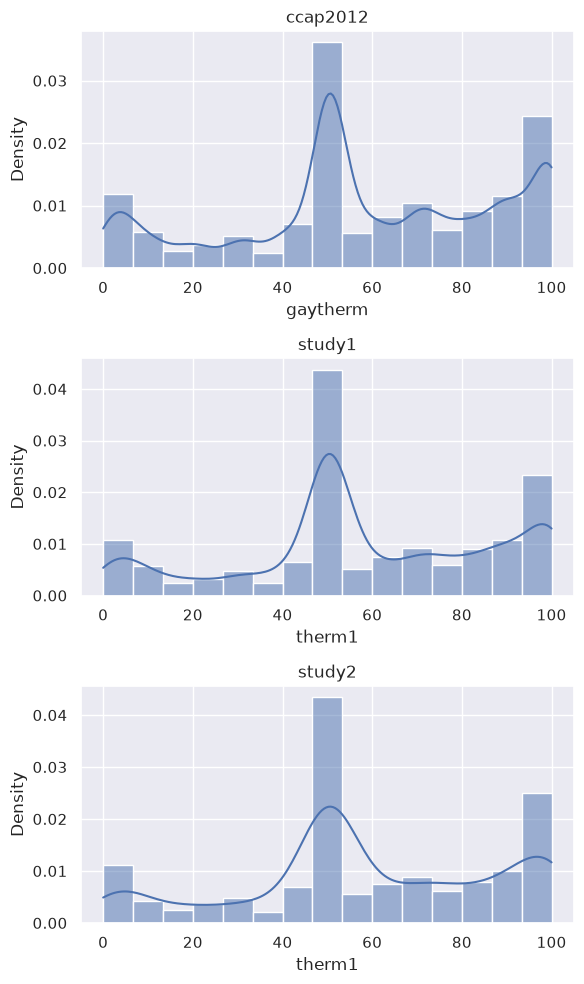

In [16]:
bin_edges = np.linspace(0, 100, 16)

fig, ax = plt.subplots(3, 1, figsize=(6, 10))

sns.histplot(data=ccap, x='gaytherm', bins=bin_edges, stat='density', kde=True, ax=ax[0]).set(title='ccap2012')
sns.histplot(data=gay.loc[gay.study == 1, :], x='therm1', bins=bin_edges, stat='density', kde=True, ax=ax[1]).set(title='study1')
sns.histplot(data=gay.loc[gay.study == 2, :], x='therm1', bins=bin_edges, stat='density', kde=True, ax=ax[2]).set(title='study2')

plt.tight_layout()

Q5

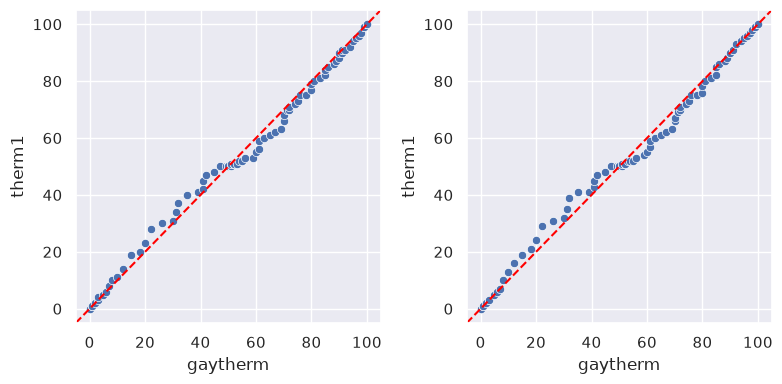

In [36]:
fig, ax = plt.subplots(1,2, figsize=(8,4))

sns.scatterplot(x=ccap['gaytherm'].quantile(np.linspace(0, 1, 101)), y=gay.loc[gay.study == 1, 'therm1'].quantile(np.linspace(0, 1, 101)),ax=ax[0])
ax[0].axline((0,0), slope=1, color='red', linestyle='--')

sns.scatterplot(x=ccap['gaytherm'].quantile(np.linspace(0, 1, 101)), y=gay.loc[gay.study == 2, 'therm1'].quantile(np.linspace(0, 1, 101)),ax=ax[1])
ax[1].axline((0,0), slope=1, color='red', linestyle='--')

plt.tight_layout();


### 3.9.3 UN 총회 투표

In [42]:
from sklearn.cluster import KMeans

In [37]:
unvo = pd.read_csv('unvoting.csv')
unvo.head()

,Year,CountryAbb,CountryName,idealpoint,PctAgreeUS,PctAgreeRUSSIA
0,1946,USA,United States of America,1.713689,1.0,0.214286
1,1947,USA,United States of America,1.812884,1.0,0.263158
2,1948,USA,United States of America,1.936166,1.0,0.127451
3,1949,USA,United States of America,1.876619,1.0,0.111111
4,1950,USA,United States of America,1.810646,1.0,0.173077


In [38]:
unvo.isna().sum()

Year              0
CountryAbb        0
CountryName       0
idealpoint        0
PctAgreeUS        1
PctAgreeRUSSIA    5
dtype: int64

In [41]:
unvo.shape

(9120, 6)

In [39]:
unvo1989 = unvo.loc[unvo.Year == 1989, ['idealpoint', 'PctAgreeUS']].copy()
unvo2012 = unvo.loc[unvo.Year == 2012, ['idealpoint', 'PctAgreeUS']].copy()

In [43]:
un1989kmeans = KMeans(n_clusters=2, n_init=5)
un2012kmeans = KMeans(n_clusters=2, n_init=5)


un1989kmeans.fit(unvo1989)
un2012kmeans.fit(unvo2012)

un1989_labels = un1989kmeans.predict(unvo1989)
un2012_labels = un2012kmeans.predict(unvo2012)

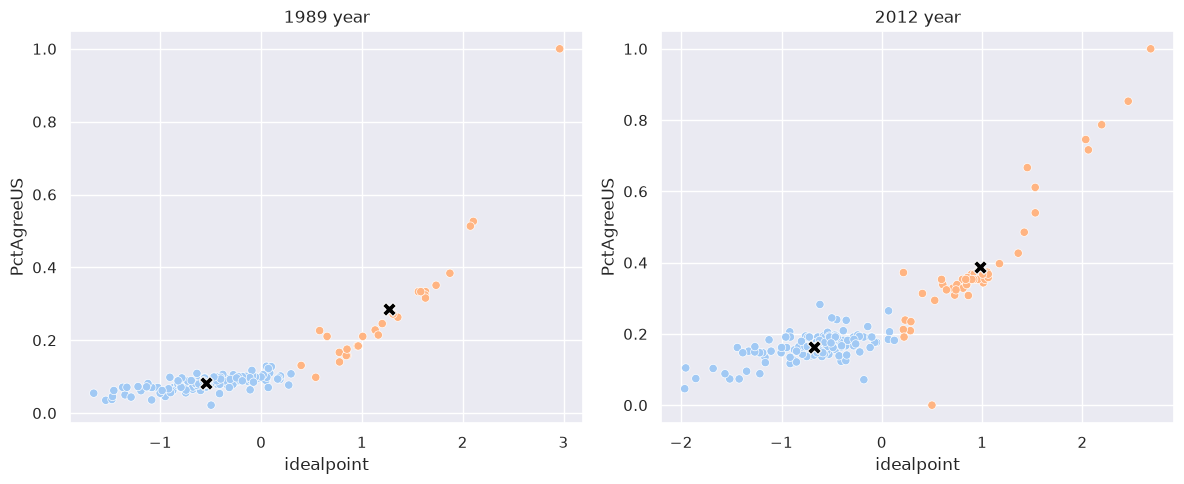

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=unvo1989, x='idealpoint', y='PctAgreeUS', hue=un1989_labels, legend=False,
    palette='pastel', ax=ax[0]
).set(title='1989 year')

sns.scatterplot(
    x=un1989kmeans.cluster_centers_[:,0], y=un1989kmeans.cluster_centers_[:,1],
    legend=False, color='black', s=100, marker='X', ax=ax[0]
)

sns.scatterplot(
    data=unvo2012, x='idealpoint', y='PctAgreeUS', hue=un2012_labels, legend=False,
    palette='pastel', ax=ax[1]
).set(title='2012 year')

sns.scatterplot(
    x=un2012kmeans.cluster_centers_[:,0], y=un2012kmeans.cluster_centers_[:,1],
    legend=False, color='black', s=100, marker='X', ax=ax[1]
)

plt.tight_layout()